In [1]:
!pip install prophet pandas matplotlib

In [2]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('AmericanElectricPower_hourly.csv')
df = df.rename(columns={'Datetime': 'ds', 'AEP_MW': 'y'})
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds')

In [4]:
df

,ds,y
2183,2004-10-01 01:00:00,12379.0
2184,2004-10-01 02:00:00,11935.0
2185,2004-10-01 03:00:00,11692.0
2186,2004-10-01 04:00:00,11597.0
2187,2004-10-01 05:00:00,11681.0
...,...,...
116157,2018-08-02 20:00:00,17673.0
116158,2018-08-02 21:00:00,17303.0
116159,2018-08-02 22:00:00,17001.0
116160,2018-08-02 23:00:00,15964.0


In [5]:
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)


model.fit(df)

DEBUG:cmdstanpy:input tempfile: /tmp/tmpqi_0ox93/n7eawbtn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqi_0ox93/8tmx2kg5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=90696', 'data', 'file=/tmp/tmpqi_0ox93/n7eawbtn.json', 'init=/tmp/tmpqi_0ox93/8tmx2kg5.json', 'output', 'file=/tmp/tmpqi_0ox93/prophet_model05q5wwy9/prophet_model-20250417070714.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:07:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:08:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [7]:
# 创建未来365天（每小时）
future = model.make_future_dataframe(periods=365*24, freq='H')

# 预测
forecast = model.predict(future)

/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


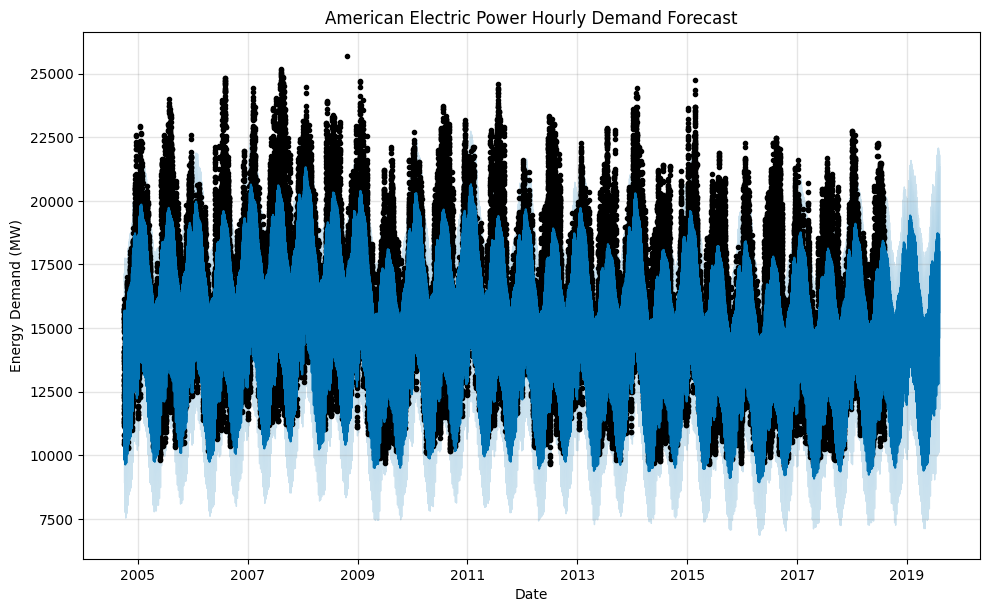

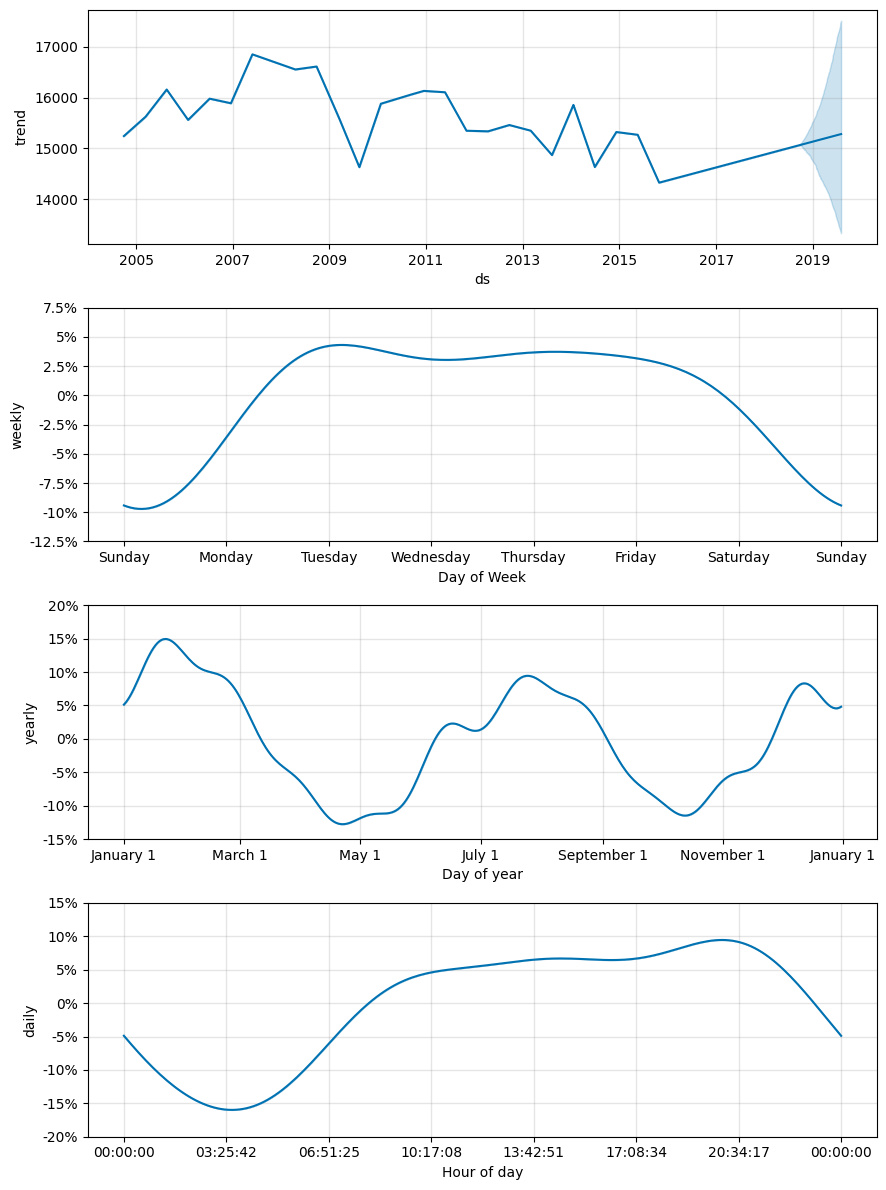

In [8]:
# 绘制预测结果
fig1 = model.plot(forecast)
plt.title('American Electric Power Hourly Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Energy Demand (MW)')
plt.show()

# 分解趋势和季节性
fig2 = model.plot_components(forecast)
plt.show()

In [9]:
# 保存预测数据
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('prophet_forecast.csv')

# 保存图表
fig1.savefig('forecast_plot.png')
fig2.savefig('components_plot.png')